# Phase 3: Text Classification (Neural)

**Dataset:** `szzs1693/intro-nlp-thai-news` — 3 categories: `politics`, `economics`, `social`

In [1]:
# Setup Thai font for matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

!wget -q -O thsarabunnew-webfont.ttf https://github.com/PyThaiNLP/prachathai-67k/raw/master/thsarabunnew-webfont.ttf

fm.fontManager.addfont("thsarabunnew-webfont.ttf")
plt.rc('font', family='TH Sarabun New')

## 1. Load Dataset

In [2]:
from datasets import load_dataset
ds = load_dataset("szzs1693/intro-nlp-thai-news")
df = ds["train"].to_pandas()
df.head()

,url,date,title,body_text,category,source
0,https://prachatai.com/print/2575,2005-02-03 02:09:00,ปากคำแก๊งหน้าดารา : อันธพาลกวนเมือง หรือ?,คดีซามูไรผมแดงครั้งนั้น กลายเป็นข่าวใหญ่โตทั้ง...,social,prachathai
1,https://prachatai.com/print/4921,2005-07-16 10:17:00,วิษณุแจงออก พ.ร.ก.. ฉุกเฉินเพื่อบูรณาการกฎหมาย,[1]\nประชาไท15 ก.ค. 2548 นายวิษณุ เครืองาม รอ...,politics,prachathai
2,https://prachatai.com/print/4923,2005-07-16 10:18:00,คำอธิบายพระราชกำหนดบริหารราชการในสถานการณ์ฉุกเ...,ภายหลังการประชุมคณะรัฐนตรีนัดพิเศษ นายวิษณุ เค...,politics,prachathai
3,https://prachatai.com/print/4939,2005-07-18 01:49:00,อนุกรรมการสมานฉันท์ฯถกพรก.ฉุกเฉิน,นายอับดุลอาซิซ ตาเดอินทร์ รองนายกสมาคมยุวมุสลิ...,politics,prachathai
4,https://prachatai.com/print/4945,2005-07-18 16:26:00,"โพลระบุ ""คน 3 จว.ใต้-กทม."" หนุนรัฐออกกม.สถานกา...",สำนักวิจัยเอแบคโพลล์ มหาวิทยาลัยอัสสัมชัญ ได้ส...,politics,prachathai


In [3]:
print(f"Shape: {df.shape}")
print(f"\nNull values:\n{df.isnull().sum()}")
print(f"\nDtypes:\n{df.dtypes}")

Shape: (6603, 6)

Null values:
url          0
date         0
title        0
body_text    0
category     0
source       0
dtype: int64

Dtypes:
url                     str
date         datetime64[us]
title                   str
body_text               str
category                str
source                  str
dtype: object


## 2. Preprocessing

ภาษาไทยไม่มีช่องว่างระหว่างคำ ต้องแบ่งคำ (word segmentation) ด้วยตัวเองก่อนส่งเข้า library อื่น ๆ ไปใช้งาน

ใช้ `pythainlp` `newmm` engine (dictionary-based maximum matching), แล้วเชื่อมด้วยช่องวาง (space) เพื่อให้ `TfidfVectorizer` เข้าใจและแบ่งคำได้

In [4]:
%pip install pythainlp

Note: you may need to restart the kernel to use updated packages.


In [5]:
from pythainlp.tokenize import word_tokenize

def tokenize(text: str) -> str:
    tokens = word_tokenize(text, engine="newmm", keep_whitespace=False)
    return " ".join(tokens)

In [6]:
from tqdm import tqdm
# This cell is slow (~5–10 min depending on hardware). Run once and proceed.
tqdm.pandas(desc="Tokenizing")
df["tokenized_text"] = df["body_text"].progress_apply(tokenize)

Tokenizing: 100%|██████████████████████████| 6603/6603 [00:40<00:00, 162.27it/s]


In [7]:
# Sanity check — compare raw vs tokenized for one article
sample = df.iloc[0]
print("=== RAW (first 300 chars) ===")
print(sample["body_text"][:300])
print("\n=== TOKENIZED (first 300 chars) ===")
print(sample["tokenized_text"][:300])

=== RAW (first 300 chars) ===
คดีซามูไรผมแดงครั้งนั้น กลายเป็นข่าวใหญ่โตทั้งหนังสือพิมพ์ วิทยุและทีวี ทำให้คนรู้จักกลุ่มของพวกเราไปทั้งประเทศ ผมไม่อยากพูดถึง เพราะมันเป็นความผิดที่ทำให้เราถูกเกลียดชัง ถูกจับจ้องมองทั้งจากตำรวจและจากแหล่งสื่อต่างๆ
คดีที่เกิดขึ้นหลายครั้งต่อมา ทั้งสื่อ ตำรวจ และสังคมต่างพากันประโคมข่าวว่า เป็นกลุ่

=== TOKENIZED (first 300 chars) ===
คดี ซามูไร ผม แดง ครั้งนั้น กลาย เป็นข่าว ใหญ่โต ทั้ง หนังสือพิมพ์ วิทยุ และ ทีวี ทำให้ คนรู้จัก กลุ่ม ของ พวกเรา ไป ทั้ง ประเทศ ผม ไม่ อยาก พูดถึง เพราะ มัน เป็นความ ผิดที่ ทำให้ เรา ถูก เกลียดชัง ถูกจับ จ้องมอง ทั้ง จาก ตำรวจ และ จาก แหล่ง สื่อ ต่างๆ 
 คดี ที่ เกิดขึ้น หลาย ครั้งต่อมา ทั้ง สื่อ ตำ


## 3. Trai / Test Split

We use a **80 / 20** stratified split to preserve class balance across all three sets.

**3.1 Stratified Train/Test Split (Category + Source)**

In [8]:
# สร้าง composite key เพื่อ stratify ทั้ง category และ source
df["stratify_key"] = df["category"] + "_" + df["source"]

from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["stratify_key"],
    random_state=42
)

print("Train size:", len(train_df))
print("Test size:", len(test_df))

Train size: 5282
Test size: 1321


**3.2 Prepare X, y**

In [9]:
X_train = train_df["tokenized_text"]
X_test = test_df["tokenized_text"]


y_train = train_df["category"]
y_test = test_df["category"]

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

**Part 2: Model**

**STEP 1: Train Word2Vec**

In [10]:
%pip install gensim

Note: you may need to restart the kernel to use updated packages.


In [11]:
# Create embedding only for training data
sentences = train_df["tokenized_text"].apply(lambda x: x.split())

from gensim.models import Word2Vec

w2v_model = Word2Vec(
    sentences,
    vector_size=100,   # ขนาด embedding
    window=5,
    min_count=2,
    workers=4,
    sg=1               # 1 = skip-gram
)

**STEP 2 : สร้าง Tokenizer**

เพื่อให้เข้าใจว่าความยาวของ sequence ควรเป็นเท่าไรในการ train เราจึง plot distibution ของจำนวน token (token length) ก่อนจะเลือกค่า `max_len` ที่เหมาะสม

Token length stats (train set):
count     5282.000000
mean       953.848921
std       1078.452148
min         65.000000
50%        648.000000
75%       1097.000000
90%       1847.800000
95%       2700.700000
99%       5629.750000
max      15020.000000


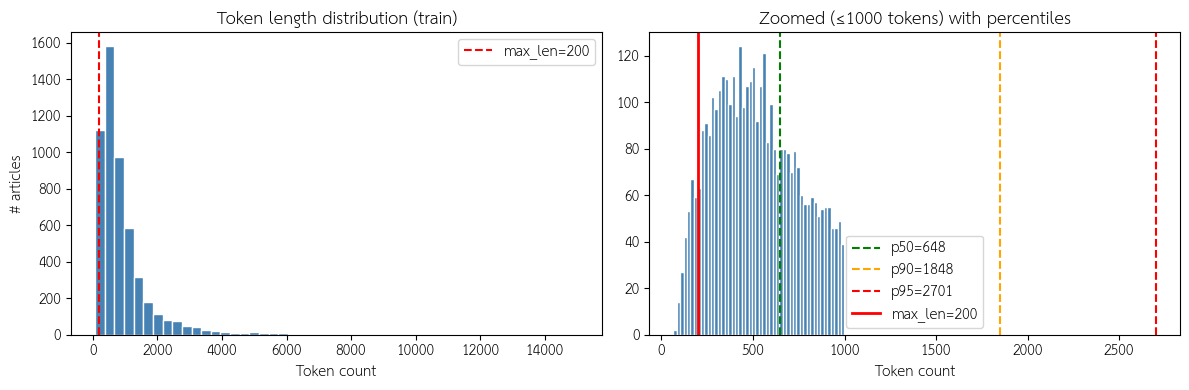

max_len=200: covers 5.3% of training articles
max_len=300: covers 14.3% of training articles
max_len=400: covers 25.0% of training articles
max_len=500: covers 35.8% of training articles


In [12]:
# Check token length distribution to pick a good max_len
lengths = train_df["tokenized_text"].apply(lambda x: len(x.split()))

print("Token length stats (train set):")
print(lengths.describe(percentiles=[0.5, 0.75, 0.90, 0.95, 0.99]).to_string())

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(lengths, bins=50, color="steelblue", edgecolor="white")
axes[0].axvline(200, color="red", linestyle="--", label="max_len=200")
axes[0].set_xlabel("Token count")
axes[0].set_ylabel("# articles")
axes[0].set_title("Token length distribution (train)")
axes[0].legend()

axes[1].hist(lengths[lengths <= 1000], bins=50, color="steelblue", edgecolor="white")
for p, c in [(50, "green"), (90, "orange"), (95, "red")]:
    v = lengths.quantile(p / 100)
    axes[1].axvline(v, color=c, linestyle="--", label=f"p{p}={v:.0f}")
axes[1].axvline(200, color="red", linestyle="-", linewidth=2, label="max_len=200")
axes[1].set_xlabel("Token count")
axes[1].set_title("Zoomed (≤1000 tokens) with percentiles")
axes[1].legend()

plt.tight_layout()
plt.show()

# Proportion of articles that fit within max_len
for threshold in [200, 300, 400, 500]:
    pct = (lengths <= threshold).mean() * 100
    print(f"max_len={threshold}: covers {pct:.1f}% of training articles")

In [13]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

tokenizer = Tokenizer()
tokenizer.fit_on_texts(train_df["tokenized_text"])

X_train_seq = tokenizer.texts_to_sequences(train_df["tokenized_text"])
X_test_seq  = tokenizer.texts_to_sequences(test_df["tokenized_text"])

max_len = 700

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, truncating='post')
X_test_pad  = pad_sequences(X_test_seq, maxlen=max_len, truncating='post')

2026-03-13 23:31:20.456818: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-13 23:31:20.457043: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-13 23:31:20.479515: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-13 23:31:22.200937: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation or

**STEP 3: สร้าง Embedding Matrix จาก Word2Vec**

In [14]:
import numpy as np

embedding_dim = 100
word_index = tokenizer.word_index
vocab_size = len(word_index) + 1

embedding_matrix = np.zeros((vocab_size, embedding_dim))

for word, i in word_index.items():
    if word in w2v_model.wv:
        embedding_matrix[i] = w2v_model.wv[word]

**STEP 4: สร้าง RNN**

In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout

rnn_model = Sequential([
    Embedding(input_dim=vocab_size,
              output_dim=embedding_dim,
              weights=[embedding_matrix],
              trainable=False),
    SimpleRNN(64),
    Dropout(0.5),
    Dense(len(le.classes_), activation="softmax")
])

rnn_model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

rnn_model.summary()

2026-03-13 23:31:29.325440: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │     5,026,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,026,500 (19.17 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 5,026,500 (19.17 MB)

**STEP 5: สร้าง LSTM Model**

In [16]:
from tensorflow.keras.layers import LSTM

lstm_model = Sequential([
    Embedding(input_dim=vocab_size,
              output_dim=embedding_dim,
              weights=[embedding_matrix],
              trainable=False),
    LSTM(64),
    Dropout(0.5),
    Dense(len(le.classes_), activation="softmax")
])

lstm_model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │     5,026,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,026,500 (19.17 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 5,026,500 (19.17 MB)

**STEP 6: Train (ใช้ Validation)**

In [17]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

checkpoint_rnn = ModelCheckpoint(
    "best_rnn.keras",
    monitor="loss",
    save_best_only=True,
)
early_stop_rnn = EarlyStopping(
    monitor="loss",
    patience=3,
    restore_best_weights=True
)

history_rnn = rnn_model.fit(
    X_train_pad, y_train_enc,
    epochs=20,
    batch_size=32,
    callbacks=[checkpoint_rnn, early_stop_rnn]
)

Epoch 1/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 6s 34ms/step - accuracy: 0.4551 - loss: 1.1220
Epoch 2/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.4502 - loss: 1.0922
Epoch 3/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 6s 33ms/step - accuracy: 0.5034 - loss: 0.9907
Epoch 4/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 6s 34ms/step - accuracy: 0.5350 - loss: 0.9601
Epoch 5/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 14s 84ms/step - accuracy: 0.6132 - loss: 0.8940
Epoch 6/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.5437 - loss: 0.9622
Epoch 7/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.5108 - loss: 0.9954
Epoch 8/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.5733 - loss: 0.9166


In [18]:
checkpoint_lstm = ModelCheckpoint(
    "best_lstm.keras",
    monitor="loss",
    save_best_only=True,
)
early_stop_lstm = EarlyStopping(
    monitor="loss",
    patience=3,
    restore_best_weights=True
)

history_lstm = lstm_model.fit(
    X_train_pad, y_train_enc,
    epochs=20,
    batch_size=32,
    callbacks=[checkpoint_lstm, early_stop_lstm]
)

Epoch 1/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 15s 85ms/step - accuracy: 0.5680 - loss: 0.9297
Epoch 2/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 14s 85ms/step - accuracy: 0.6605 - loss: 0.8253
Epoch 3/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 14s 84ms/step - accuracy: 0.5636 - loss: 0.9487
Epoch 4/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 14s 84ms/step - accuracy: 0.6104 - loss: 0.8916
Epoch 5/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 14s 82ms/step - accuracy: 0.7120 - loss: 0.7554
Epoch 6/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 14s 85ms/step - accuracy: 0.7119 - loss: 0.7383
Epoch 7/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 14s 85ms/step - accuracy: 0.7007 - loss: 0.7592
Epoch 8/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 14s 82ms/step - accuracy: 0.7098 - loss: 0.7433
Epoch 9/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 13s 80ms/step - accuracy: 0.7454 - loss: 0.6605
Epoch 10/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 13s 80ms/step - accuracy: 0.7295 - loss: 0.7030
Epoch 11/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 14s 81ms/step - accuracy: 0.7594 - loss: 0.6378
Epoch 12/20
166/166 ━━━━━━━━━━

In [19]:
import numpy as np
from sklearn.metrics import classification_report, f1_score

# Predict
y_pred_rnn = np.argmax(rnn_model.predict(X_test_pad), axis=1)
y_pred_lstm = np.argmax(lstm_model.predict(X_test_pad), axis=1)

print("=== RNN ===")
print(classification_report(y_test_enc, y_pred_rnn, target_names=le.classes_))

print("=== LSTM ===")
print(classification_report(y_test_enc, y_pred_lstm, target_names=le.classes_))

# F1 Macro
f1_rnn = f1_score(y_test_enc, y_pred_rnn, average="macro")
f1_lstm = f1_score(y_test_enc, y_pred_lstm, average="macro")

print("F1 Macro RNN:", f1_rnn)
print("F1 Macro LSTM:", f1_lstm)

42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step
=== RNN ===
              precision    recall  f1-score   support

   economics       0.44      0.79      0.57       441
    politics       0.87      0.23      0.37       440
      social       0.38      0.35      0.36       440

    accuracy                           0.46      1321
   macro avg       0.56      0.46      0.43      1321
weighted avg       0.56      0.46      0.43      1321

=== LSTM ===
              precision    recall  f1-score   support

   economics       0.78      0.72      0.75       441
    politics       0.77      0.77      0.77       440
      social       0.66      0.71      0.68       440

    accuracy                           0.73      1321
   macro avg       0.74      0.73      0.73      1321
weighted avg       0.74      0.73      0.73      1321

F1 Macro RNN: 0.43233789835772307
F1 Macro LSTM: 0.7336568513653723


**STEP 7: Evaluate + F1 Macro**

In [20]:
import numpy as np
from sklearn.metrics import classification_report, f1_score

# Predict
y_pred_rnn = np.argmax(rnn_model.predict(X_test_pad), axis=1)
y_pred_lstm = np.argmax(lstm_model.predict(X_test_pad), axis=1)

print("=== RNN ===")
print(classification_report(y_test_enc, y_pred_rnn, target_names=le.classes_))

print("=== LSTM ===")
print(classification_report(y_test_enc, y_pred_lstm, target_names=le.classes_))

# F1 Macro
f1_rnn = f1_score(y_test_enc, y_pred_rnn, average="macro")
f1_lstm = f1_score(y_test_enc, y_pred_lstm, average="macro")

print("F1 Macro RNN:", f1_rnn)
print("F1 Macro LSTM:", f1_lstm)

42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step
=== RNN ===
              precision    recall  f1-score   support

   economics       0.44      0.79      0.57       441
    politics       0.87      0.23      0.37       440
      social       0.38      0.35      0.36       440

    accuracy                           0.46      1321
   macro avg       0.56      0.46      0.43      1321
weighted avg       0.56      0.46      0.43      1321

=== LSTM ===
              precision    recall  f1-score   support

   economics       0.78      0.72      0.75       441
    politics       0.77      0.77      0.77       440
      social       0.66      0.71      0.68       440

    accuracy                           0.73      1321
   macro avg       0.74      0.73      0.73      1321
weighted avg       0.74      0.73      0.73      1321

F1 Macro RNN: 0.43233789835772307
F1 Macro LSTM: 0.7336568513653723


**STEP 8: Confusion Matrix (Normalized)**

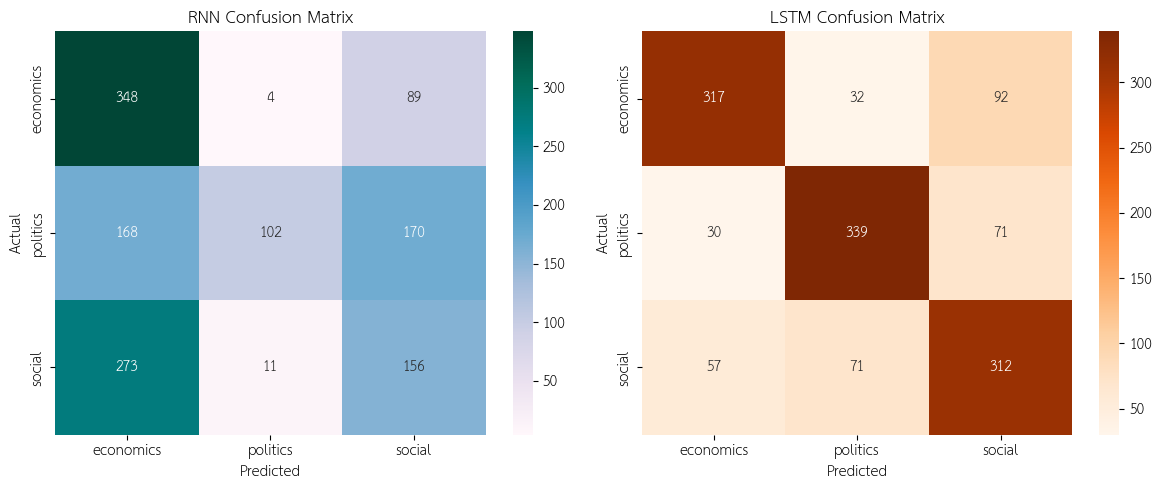


=== Class Accuracy RNN ===
economics: 0.79
politics: 0.23
social: 0.35

=== Class Accuracy LSTM ===
economics: 0.72
politics: 0.77
social: 0.71


In [21]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

labels_for_plot = le.classes_

cm_lstm = confusion_matrix(y_test_enc, y_pred_lstm, labels=range(len(labels_for_plot)))
cm_rnn = confusion_matrix(y_test_enc, y_pred_rnn, labels=range(len(labels_for_plot)))

fig, axes = plt.subplots(1, 2, figsize=(12,5))

# RNN
sns.heatmap(cm_rnn,
            annot=True,
            fmt="d",
            cmap="PuBuGn",
            xticklabels=labels_for_plot,
            yticklabels=labels_for_plot,
            ax=axes[0])
axes[0].set_title("RNN Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")


# LSTM
sns.heatmap(cm_lstm,
            annot=True,
            fmt="d",
            cmap="Oranges",
            xticklabels=labels_for_plot,
            yticklabels=labels_for_plot,
            ax=axes[1])
axes[1].set_title("LSTM Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

print("\n=== Class Accuracy RNN ===")
for i, label in enumerate(labels_for_plot):
    acc = cm_rnn[i, i] / cm_rnn[i].sum()
    print(f"{label}: {acc:.2f}")

print("\n=== Class Accuracy LSTM ===")
for i, label in enumerate(labels_for_plot):
    acc = cm_lstm[i, i] / cm_lstm[i].sum()
    print(f"{label}: {acc:.2f}")

**3.8 กราฟเปรียบเทียบ**

**Note** F1 Macro คือ ค่า F1-score ที่คำนวณแยกทีละ class
แล้วเอามา **เฉลี่ยแบบไม่ถ่วงน้ำหนัก** ที่กัน Class Imbalance ถ้า dataset ไม่สมดุล

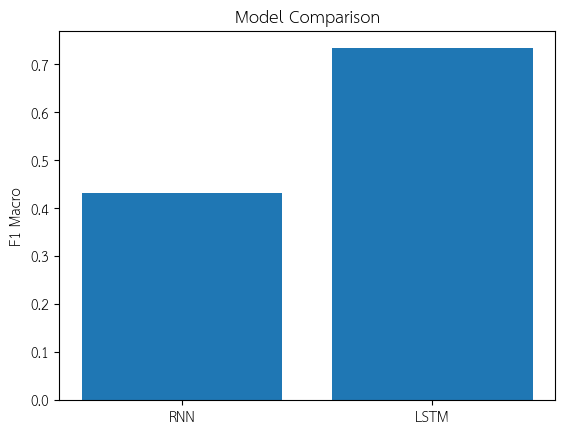

In [22]:
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt

# Assuming f1_rnn and f1_lstm are already calculated and available
# from previous cells.

models = ["RNN", "LSTM"]
scores = [f1_rnn, f1_lstm]

plt.bar(models, scores)
plt.ylabel("F1 Macro")
plt.title("Model Comparison")
plt.show()

**3.9 F1 แยกตาม Source**

In [23]:
test_df["pred_rnn"] = y_pred_rnn
test_df["pred_lstm"] = y_pred_lstm
# Add the numerical encoded test categories to the test_df
test_df["encoded_category"] = y_test_enc

from sklearn.metrics import f1_score

for src in test_df["source"].unique():
    subset = test_df[test_df["source"] == src]

    # Use the encoded_category for y_true
    f1_rnn_src = f1_score(subset["encoded_category"], subset["pred_rnn"], average="macro")
    f1_lstm_src = f1_score(subset["encoded_category"], subset["pred_lstm"], average="macro")

    print(f"\nSource: {src}")
    print("RNN F1:", f1_rnn_src)
    print("LSTM F1:", f1_lstm_src)


Source: prachathai
RNN F1: 0.41580860084797094
LSTM F1: 0.726751457267271

Source: thaipbs
RNN F1: 0.5015181712968594
LSTM F1: 0.7636047107014848


## (Extra) Phase 4: Document Search with Embeddings

**Step 1 แปลง Document เป็น Vector**

ใช้ Word2Vec ที่ train ไว้แล้ว

โดยสร้าง document embedding จากค่าเฉลี่ยของ word vectors

In [24]:
import numpy as np

def document_vector(doc):
    words = tokenize(doc)
    word_vecs = []

    for word in words:
        if word in w2v_model.wv:
            word_vecs.append(w2v_model.wv[word])

    if len(word_vecs) == 0:
        return np.zeros(w2v_model.vector_size)

    return np.mean(word_vecs, axis=0)

**Step 2 สร้าง Vector ของทุก Document**

สมมติ dataset ของคุณอยู่ใน X_text

In [25]:
doc_vectors = []

for doc in X_test:
    vec = document_vector(doc)
    doc_vectors.append(vec)

doc_vectors = np.array(doc_vectors)

**Step 3 ใช้ Cosine Similarity เพื่อ Query แล้วหาเอกสารที่คล้ายที่สุด**

In [26]:
from sklearn.metrics.pairwise import cosine_similarity

query = "นโยบายเศรษฐกิจ"

query_vec = document_vector(query)

similarities = cosine_similarity([query_vec], doc_vectors)[0]

top_k = 5

top_indices = similarities.argsort()[-top_k:][::-1]

for i in top_indices:
    print("Score:", similarities[i])
    print("Document:", X_test.iloc[i][:200]) # แสดงแค่200 ตัวอักษรแรก
    print("------")

Score: 0.9694443
Document: กรมการปกครอง กระทรวง หมาด ไทย มี คำสั่ง โยกย้าย นายอำเภอ จำนวน ทั้งหมด 252 ราย พร้อม ขยับ 3 รอง ผู้ว่าฯ เข้า กรุ นั่ง ที่ปรึกษา 
 17 ม.ค. 2558 กรมการปกครอง กระทรวง หมาด ไทย ได้ มี คำสั่ง โยกย้าย นายอำ
------
Score: 0.9653646
Document: 15 ธ.ค. 53 - ดร. พงศ์ เทพ อัคร ธน กุล ผู้อำนวยการ ศูนย์ ความเป็นเลิศ ด้าน เทคโนโลยีชีวภาพ เกษตร สถาบันวิจัย เพื่อ การพัฒนา ประเทศ ไทย (TDRI) เปิดเผย เกี่ยวกับ การพัฒนา กำลังคน เพื่อ งานวิจัย ข้าว ไทย 
------
Score: 0.9639956
Document: กรุงเทพ โพลล์ โดย ศูนย์ วิจัย มหาวิทยาลัย กรุงเทพ ร่วมกับ คณะเศรษฐศาสตร์ เปิดเผย ผลสำรวจ ความเห็น   นักเศรษฐศาสตร์ จาก 25 องค์กร จำนวน 63 คน เรื่อง “ คาดการณ์ แนวโน้ม GDP และ ทิศทาง ดอกเบี้ย ” พบ ว่า 
------
Score: 0.96306163
Document: 20 ก.พ. 2557 - เดลินิวส์ [1] รายงาน ว่า เมื่อ วันที่ 20 ก.พ. เวลา 13.00 น. ที่วัด เขา คราม ม. 4 ต. เขา คราม อ. เมือง จ. กระบี่ นาย มานะ จรุง เกียรติ กุล นายอำเภอ เมือง กระบี่ พร้อมด้วย นาย สาคร เกี่ยว
------
Score: 0.9629815
Document: 16 พ . ย . 2558 เว็บไซต์ กอง บัง